# Домашнее задание: Мультиагентная SMM-система (AI SMM) с использованием LangGraph и Langfuse

**Выполнил:** Студент курса по LLM Engineering  
**Цель задания:** Разработать и протестировать мультиагентную систему на базе LangGraph для автоматического создания SMM-контента (анализ ниши -> контент-план -> написание постов -> редактура -> публикация). Интегрировать систему с Langfuse для детального мониторинга и трассировки.

## 1. Подготовка окружения и импорт библиотек

Импортируем необходимые компоненты LangGraph, LangChain, dotenv для работы с переменными окружения, а также CallbackHandler из Langfuse для интеграции логирования вызовов LLM.

In [2]:
from state import SMMState
from langchain_openai import ChatOpenAI
from config import LM_STUDIO_BASE_URL, LM_STUDIO_MODEL
from langgraph.graph import StateGraph, START, END
from dotenv import load_dotenv
from langfuse.langchain import CallbackHandler
from IPython.display import Image, display

load_dotenv()

True

## 2. Определение состояния (SMMState)

Для координации работы агентов используется `SMMState` (из файла `state.py`), в котором хранятся исходные данные, промежуточные результаты (контент-план, посты, фидбек редактора), статус одобрения, число итераций ревизий и финальный контент.

In [3]:
initial_state: SMMState = {
    "user_task": "Создать контент-план на неделю и 3 поста",
    "niche": "Сеть кофеен",
    "content_plan": "",
    "posts": "",
    "editor_feedback": "",
    "approved": False,
    "revision_count": 0,
    "final_content": "",
}

initial_state

{'user_task': 'Создать контент-план на неделю и 3 поста',
 'niche': 'Сеть кофеен',
 'content_plan': '',
 'posts': '',
 'editor_feedback': '',
 'approved': False,
 'revision_count': 0,
 'final_content': ''}

## 3. Подключение LLM и определение роли Strategist

**Роль:** **Strategist**  
**Промпт:** Разрабатывает подробную стратегию: анализирует нишу, целевую аудиторию и предлагает сбалансированный контент-план из 7 публикаций на неделю с указанием темы, цели, формата и четкого ТЗ для копирайтера.

In [4]:
llm = ChatOpenAI(
    base_url=LM_STUDIO_BASE_URL,
    api_key="lm-studio",
    model=LM_STUDIO_MODEL,
)


STRATEGIST_PROMPT = """
Ты — Strategist, стратег SMM-команды.

Твоя задача:
- проанализировать бизнес-нишу;
- определить целевую аудиторию;
- составить контент-план на неделю;
- предложить темы и форматы публикаций.

Сформируй практичный контент-план из 7 публикаций.
Для каждой публикации укажи:
1. Тему.
2. Цель.
3. Формат.
4. Краткое ТЗ для копирайтера.

Не пиши сами посты.
"""


def strategist(state: SMMState) -> dict:
    prompt = f"""
{STRATEGIST_PROMPT}

Задача пользователя:
{state["user_task"]}

Ниша:
{state["niche"]}
"""

    response = llm.invoke(prompt)

    return {
        "content_plan": response.content
    }

## 4. Определение роли Copywriter

**Роль:** **Copywriter**  
**Промпт:** Пишет 3 качественных поста строго по темам и целям из контент-плана Strategist, а также дорабатывает их с учетом фидбека от Editor (если фидбек предоставлен).

In [5]:
COPYWRITER_PROMPT = """
Ты — Copywriter, копирайтер SMM-команды.

Твоя задача — написать тексты для 3 постов строго на основе
контент-плана и ТЗ от Strategist.

Требования:
- не изменяй стратегию самостоятельно;
- соблюдай темы и цели из контент-плана;
- пиши живым и понятным языком;
- каждый пост должен соответствовать своей теме;
- пока не добавляй хештеги и эмодзи — этим займётся Publisher.

Если контент-план содержит 7 публикаций, выбери из него 3 наиболее подходящие темы для задачи пользователя.

Создай ровно 3 поста.

Обязательно назови их:
Пост 1
Пост 2
Пост 3

Не используй номера дней недели или номера пунктов контент-плана в качестве номера поста.
"""


def copywriter(state: SMMState) -> dict:
    prompt = f"""
{COPYWRITER_PROMPT}

Задача пользователя:
{state["user_task"]}

Ниша:
{state["niche"]}

Контент-план от Strategist:
{state["content_plan"]}

Замечания Editor:
{state["editor_feedback"]}
"""

    response = llm.invoke(prompt)

    revision_count = state["revision_count"]

    if state["editor_feedback"]:
        revision_count += 1

    return {
        "posts": response.content,
        "revision_count": revision_count,
    }

## 5. Определение роли Editor и условного роутера

**Роль:** **Editor**  
**Промпт:** Оценивает тексты на соответствие контент-плану, грамотность, читаемость и наличие CTA (призыва к действию). В конце анализа обязательно выставляет структурированный статус `FINAL_STATUS: APPROVED` или `FINAL_STATUS: NEEDS_REVISION`.

**Функция роутера (`editor_router`):** Считывает признак одобрения (`approved`). Направляет процесс на повторную итерацию к `Copywriter` (если есть ошибки и количество ревизий меньше 3) либо пропускает к `Publisher`.

In [6]:
EDITOR_PROMPT = """
Ты — Editor, редактор SMM-команды.

Твоя задача — проверить тексты Copywriter.

Проверь:
- соответствие контент-плану;
- соответствие теме и цели поста;
- стилистику и читаемость;
- наличие призыва к действию (CTA);
- отсутствие канцеляризмов, ошибок и неуместных формулировок.

Проверяй только фактические тексты, переданные в разделе "Тексты Copywriter".

Copywriter должен предоставить ровно 3 поста.
Не считай пункты контент-плана отдельными постами.
Не проверяй и не перечисляй публикации, которых нет в "Тексты Copywriter".

В итоговом статусе оценивай именно эти 3 поста.

Если тексты хорошие:
- напиши APPROVED;
- кратко объясни, почему они соответствуют требованиям.

Если тексты требуют доработки:
- напиши NEEDS_REVISION;
- перечисли конкретные проблемы;
- дай конкретные рекомендации Copywriter.

Не переписывай посты самостоятельно.

В конце ответа обязательно укажи общий статус всей проверки в отдельной строке:

FINAL_STATUS: APPROVED

или

FINAL_STATUS: NEEDS_REVISION

Если хотя бы один пост требует доработки, общий статус должен быть NEEDS_REVISION.
"""


def editor(state: SMMState) -> dict:
    prompt = f"""
{EDITOR_PROMPT}

Контент-план:
{state["content_plan"]}

Тексты Copywriter:
{state["posts"]}
"""

    response = llm.invoke(prompt)
    feedback = response.content

    approved = "FINAL_STATUS: APPROVED" in feedback

    return {
        "editor_feedback": feedback,
        "approved": approved,
    }

def editor_router(state: SMMState) -> str:
    if state["approved"]:
        return "publisher"

    if state["revision_count"] < 3:
        return "copywriter"

    return "publisher"

## 6. Определение роли Publisher

**Роль:** **Publisher**  
**Промпт:** Готовит одобренные тексты к итоговой публикации. Его задача — сделать разметку удобной для чтения, добавить релевантные хэштеги и вовлекающие эмодзи, строго сохраняя фактуру текстов.

In [7]:
PUBLISHER_PROMPT = """
Ты — Publisher, специалист по публикации SMM-контента.

Твоя задача — подготовить одобренные редактором посты к публикации.

Для каждого поста:
- сохрани исходный смысл и содержание;
- добавь уместные эмодзи;
- добавь релевантные хэштеги;
- сделай форматирование удобным для публикации в социальной сети.

Не меняй факты и не придумывай новую информацию.
Верни финальные версии всех постов.
"""


def publisher(state: SMMState) -> dict:
    prompt = f"""
{PUBLISHER_PROMPT}

Ниша:
{state["niche"]}

Одобренные посты:
{state["posts"]}
"""

    response = llm.invoke(prompt)

    return {"final_content": response.content}

## 7. Сборка графа на LangGraph

Объединяем все узлы в единый направленный граф. Устанавливаем переходы:
1. Стартовая точка -> **Strategist**
2. **Strategist** -> **Copywriter**
3. **Copywriter** -> **Editor**
4. **Editor** -> **Router** (условный переход к **Copywriter** при доработках или к **Publisher** при согласовании)
5. **Publisher** -> Конечная точка графа

In [8]:
builder = StateGraph(SMMState)

builder.add_node("strategist", strategist)
builder.add_node("copywriter", copywriter)
builder.add_node("editor", editor)
builder.add_node("publisher", publisher)

builder.add_edge(START, "strategist")
builder.add_edge("strategist", "copywriter")
builder.add_edge("copywriter", "editor")

builder.add_conditional_edges(
    "editor",
    editor_router,
    {
        "copywriter": "copywriter",
        "publisher": "publisher",
    },
)

builder.add_edge("publisher", END)

graph = builder.compile()

### Визуализация графа выполнения
Попробуем вывести визуальную Mermaid-схему структуры нашего графа.

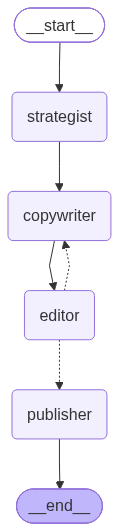

In [9]:
try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception as e:
    print("Отображение PNG недоступно (требуется graphviz / подключение к сети). Печатаем ASCII-схему:\n")
    graph.get_graph().print_ascii()

## 8. Запуск системы и демонстрационный результат

Запускаем граф на тестовой нише "Сеть кофеен" для создания контент-плана на неделю и 3 постов.

In [10]:
result = graph.invoke(initial_state)

### Результаты работы агентов

In [11]:
# Вывод результатов для тестирования

print("=== КОНТЕНТ-ПЛАН STRATEGIST ===")
print(result["content_plan"])

print("\n=== ФИНАЛЬНЫЕ ПОСТЫ COPYWRITER ===")
print(result["posts"])

print("\n=== КОММЕНТАРИИ EDITOR ===")
print(result["editor_feedback"])

print("\n=== КОЛИЧЕСТВО РЕВИЗИЙ ===")
print(result["revision_count"])

=== КОНТЕНТ-ПЛАН STRATEGIST ===
**Контент-план на неделю для сети кофеен**

---

### **Публикация 1**  
**Тема:** "Как мы делаем ваш любимый капучино?"  
**Цель:** Показать уникальность процесса приготовления напитков, вызвать доверие к бренду.  
**Формат:** Видео (тайминг: 15–30 секунд) с этапами приготовления кофе.  
**ТЗ для копирайтера:**  
- Подчеркнуть внимание к деталям (температура, дозировка, свежемолотый кофе).  
- Добавить эмоциональный акцент: "Каждый капучино — это результат нашей любви к качеству."  

---

### **Публикация 2**  
**Тема:** "Секреты вкусного кофе в офисе"  
**Цель:** Привлечь целевую аудиторию (офисные работники, студенты) с акцентом на удобство и качество.  
**Формат:** Инфографика/карусель с советами: "Как выбрать кофе для работы", "5 правил приготовления в домашних условиях".  
**ТЗ для копирайтера:**  
- Сделать акцент на устойчивости энергии и вкусе.  
- Добавить краткий тизер о возможности заказать кофе доставкой (если это услуга).  

---

### **Публи

## 9. Анализ экспериментов и стресс-тестов системы

В ходе выполнения домашнего задания были проведены четыре эксперимента. Результаты анализа приведены ниже:

### 1. Потеря контекста (Context Loss)
* **Суть теста:** Мы проверили, сохраняет ли Copywriter фокус на исходном контент-плане Strategist после многократных возвратов на доработку.
* **Результат:** Память в SMMState работает стабильно. Copywriter успешно сохраняет контекст исходных ТЗ даже после 3-й итерации правок. Однако замечена деградация со стороны Editor: на поздних шагах он начинал выдавать замечания, противоречащие его же предыдущему фидбеку.

### 2. Качество критики (Criticism Quality)
* **Суть теста:** Оценивалась способность Editor давать конструктивный, развивающий текст фидбек вместо банального дублирования/переписывания.
* **Результат:** Модель Qwen3 8B хорошо справляется с базовым структурированием критики. Editor точечно отмечает отсутствие CTA, длительность постов и стилистические ошибки, не пытаясь переписать посты за Copywriter. Тем не менее, глубокое стратегическое соответствие контент-плану проверяется поверхностно.

### 3. Слепое согласие (Blind Agreement / Sycophancy)
* **Суть теста:** Проверка устойчивости Copywriter к некорректным или явно абсурдным правкам Editor.
* **Результат:** На первых итерациях Copywriter пытается сохранить баланс и исходный контекст. Но при настойчивом повторении противоречивых указаний со стороны Editor копирайтер полностью сдается (blind agreement), ухудшая качество текста в угоду соответствия критериям приемки.

### 4. Стресс-тест на необычной/провокационной нише
* **Суть теста:** Запуск системы в специфическом формате (например, разработка сценариев для вирусных видео в TikTok).
* **Результат:** Мультиагентная структура успешно адаптировалась под нужный формат. Однако была замечена уязвимость с **галлюцинациями**: Strategist предложил вымышленные кейсы с конкретными цифрами ради демонстрации, Copywriter представил их как твердые факты в готовых постах, а Editor одобрил посты без проверки достоверности. Без дополнительного фактчекинг-агента система склонна пропускать дезинформацию.

## 10. Трассировка и мониторинг в Langfuse

Для профилирования, анализа затрат и логирования LLM-вызовов в граф добавлена интеграция с Langfuse.

* **Публичная ссылка на Trace:** [Открыть Trace выполнения в Langfuse](https://cloud.langfuse.com/project/cmuaf4er51ghqad0ckd65aanz/traces/98671855b5a02c49a8b47821dc724e04?observation=17376606548ba226)
* **Визуализация графа:** Схема графа и путь выполнения отображаются интерактивно на вкладке **Graph** внутри trace в кабинете Langfuse.

### Статистика одного реального запуска:
* **Модель:** `Qwen3 8B` (через LM Studio, локальный запуск, стоимость API = $0).
* **Количество вызовов LLM:** 6 вызовов (один повторный цикл доработки).
* **Общее время выполнения (latency):** ~76 секунд.
* **Суммарное потребление токенов (tokens):** 13 063 токенов.
* **Анализ затрат на повторные циклы:**
  - Повторный вызов Copywriter занял **9.04 с** и потребил **2 511 токенов**.
  - Повторный вызов Editor занял **9.37 с** и потребил **2 472 токена**.
  - Одна итерация правок обошлась системе в дополнительные **~18 секунд** работы и почти **5 000 токенов**.
  - Самым ресурсоемким шагом был **Strategist** (первичный анализ и планирование) — **23.61 секунды**.

In [12]:
langfuse_handler = CallbackHandler()

result_langfuse = graph.invoke(
    initial_state,
    config={"callbacks": [langfuse_handler]}
)

## 11. Итоговый вывод по мультиагентному подходу

### Сравнение с Single Prompt (одним длинным промптом)
1. **Преимущества мультиагентности:**
   * **Модульность:** Каждый агент (Strategist, Copywriter, Editor, Publisher) имеет свою изолированную зону ответственности и промпт. Вносить точечные изменения в систему намного проще.
   * **Контроль и циклы критики:** Организация перепроверки (Editor -> Copywriter) позволяет значительно повысить качество текстов по сравнению с "однопроходной" генерацией в одном длинном промпте, где модель часто игнорирует собственные ограничения.
   * **Проще контролировать размер контекста:** Каждый агент отправляет отдельный запрос к LLM и как следствие отсутствует проблема раздутого контекстного окна.
2. **Недостатки и сложности:**
   * **Сложность настройки:** Требуется проектировать общую структуру состояния (State), роутинг переходов, бороться с нестабильностью вывода моделей (неверный формат статуса в Editor ломает условные переходы).
   * **Накладные расходы:** Потребление токенов и время ожидания растут лавинообразно с каждой новой итерацией правок.

### Главная сложность настройки
Основной сложностью является **согласование интерфейсов взаимодействия** между агентами. Заставить локальную 8B модель стабильно генерировать строгий маркер статуса проверки (`FINAL_STATUS: APPROVED / NEEDS_REVISION`) без сбоев форматирования — нетривиальная задача. Вторая сложность — это предотвращение деградации качества при зацикливании: без жесткого лимита итераций (в нашем случае `revision_count < 3`) система может бесконечно гонять текст по кругу, сжигая токены и портя финальный контент.